# Book-Tax Differences — a quantitative teardown 🔬
### A point-in-time calendar-time tercile long-short (Newey-West) · a pooled event-drift cross-check with a label-shuffle placebo · an era split · the earnings-persistence interaction · a 12-seed synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Persistence%3F: Not detected](https://img.shields.io/badge/Persistence%3F-Not_detected-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **a large positive book-tax difference marks less-persistent earnings and predicts lower returns** (Hanlon 2005) — splits into a *mechanism* piece and a *mispricing* piece, and on this large-cap survivor tape **both come back null**. This is distinct from every sibling on the desk: [568](../../568-effective-tax-rate/) ranks on the tax *rate*, [231](../../231-sloan-accruals/) on *total accruals*, [229](../../229-beneish-m-score/) on an *eight-signal manipulation score*. This is the statutory-grossed-up **book-minus-tax income gap**.

> ⚠️ **Data note.** EDGAR annual `IncomeLossFromContinuingOperationsBeforeIncomeTaxes...` / `IncomeTaxExpenseBenefit` / `Assets` + yfinance adjusted closes, 39 names, ends 2007-12-31 → 2025-12-31, as-of 2026-06-30. Point-in-time on the **10-K filing date**. Survivorship named on the Signal axis (current-survivors basket, skewed to the tail where the effect is *weakest*). Numbers in [`docs/results.md`](../docs/results.md) (prices fingerprint `d579ef33a57f`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from book_tax_diff import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, EV = data.load_real()
else:
    PX = EV = None
print("real cache present:", HAVE_REAL, "| events:", (0 if EV is None else len(EV)),
      "| names:", (0 if EV is None else EV['ticker'].nunique()))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'n_names': 39, 'n_events': 569, 'end_lo': '2007-12-31', 'end_hi': '2025-12-31', 'fp_prices': 'd579ef33a57f', 'share_pos_btd': 71, 'btd_med': 2.1, 'n_months': 196, 'avg_n': 29.9, 'ls_span_lo': '2010-03-31', 'ls_span_hi': '2026-06-30', 'ls_mean_bps': 20.1, 'ls_ann': 2.42, 'ls_t_iid': 0.75, 'ls_t_nw': 0.74, 'ls_sharpe': 0.19, 'ls_hit': 49, 'ls_long_bps': 151.9, 'ls_short_bps': 131.8, 'ls_turn': 0.05, 'ls_cum': 1.29, 'change_mean_bps': 37.9, 'change_t_nw': 1.79, 'change_sharpe': 0.47, 'xsec_early': 6, 'xsec_late': 37, 'drift': {63: (569, 2.8, 3.0, -0.2, -0.15, 47, 0.5674), 126: (551, 4.95, 7.42, -2.47, -1.43, 49, 0.9369), 252: (541, 15.73, 17.35, -1.62, -0.55, 49, 0.7285)}, 'mono252': (17.35, 16.22, 15.73), 'era_early_n': 94, 'era_early_bps': 29.2, 'era_early_t': 0.94, 'era_late_n': 102, 'era_late_bps': 11.8, 'era_late_t': 0.27, 'pers_n': 530, 'b_all': 0.75, 'b_low': 0.75, 'b_high': 0.752, 'pers_diff': 0.002, 'pers_t': 0.03, 'pers_r2': 0.57, 'net': {(10, 50): (15.0, 1.8, 0.55, 0.14), (20, 100): (9.8, 1.18, 0.36, 0.09)}, 'syn_null_mean': 0.31, 'syn_null_sd': 0.67, 'syn_null_fire': 0, 'syn_null_seeds': 12, 'syn_planted_bps': 62.8, 'syn_planted_t': 2.55}


real cache present: True | events: 569 | names: 39


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** (returns) | `WEAK` | calendar tercile long-short (long low-BTD, short high-BTD) **+20.1 bps/mo** (+2.4%/yr gross), one-sample *t* = +0.75, **Newey-West *t* = +0.74**; change variant NW *t* = +1.79; pooled drift mildly *anti*-Hanlon — right sign not even stable |
| **Tradability** | `MIRAGE` | net of 20 bps + 100 bps borrow: NW *t* = +0.36, Sharpe 0.09; fails **before** costs |
| **Marks fragile earnings?** | `NOT DETECTED` | persistence interaction (high-BTD − low-BTD) = +0.002 (*t* = +0.03); 0.752 vs 0.750 — identical |

> 💡 In plain words: on blue chips, **neither** the return spread **nor** the earnings-persistence engine behind it shows up. The mispricing needs the mechanism; the mechanism is absent here.

## 1 · The claim, steelmanned

Let $P_{i,y}$ be name $i$'s pretax book income for fiscal year $y$ and $T_{i,y}$ its income-tax expense, disclosed on 10-K filing date $F_{i,y}$, with statutory rate $\tau_y$ (0.35 pre-2018, 0.21 after). The **book-tax difference**, scaled by assets $A$:

$$\text{BTD}_{i,y} = \frac{P_{i,y} - T_{i,y}/\tau_y}{A_{i,y}}$$

We gross up by the **statutory** (not effective) rate on purpose — dividing by the effective rate would algebraically recover $P$ and define the gap away. The claims:

- **H₁ (persistence).** High BTD marks **less persistent** earnings: next-year ROA loads less on this-year ROA — Hanlon's mechanism.
- **H₂ (returns).** A cross-sectional long-short, long low-BTD / short high-BTD, earns a positive forward spread — the mispricing claim.
- **H₃ (tradable).** That spread survives realistic long-short costs + borrow.

We find **H₁ not supported** (interaction +0.002, *t* = +0.03), **H₂ not supported** (NW *t* = +0.74, and the pooled drift is mildly anti-Hanlon), and therefore **H₃ moot**. The literature (Hanlon 2005) documents the effect in the broad cross-section; our large-cap survivor tape supports **neither** piece — hence `WEAK` on returns (right-signed but uncertified) and `NOT DETECTED` on the mechanism.

## 2 · So what? — inference design

The primary is a **calendar-time** long-short, not a pooled event study, because balance-sheet/annual signals are persistent and filings cluster: a calendar series of monthly long-short returns lets a **Newey-West (6-lag) HAC *t*** do the honest work the desk's `REAL` bar is written against. The panel is thin, so we sort into **terciles** (not quintiles) and require ≥ 6 names. The pooled event drift + a **label-shuffle placebo** is the cross-check; the persistence axis is an **interaction OLS** graded on the *magnitude* of the slope difference (its pooled *t* ignores firm/year clustering).

## 3 · How we'd know — the protocol

- **Panel.** 569 (ticker, fiscal-year) events across 39 names, ends 2007-12-31 → 2025-12-31, each stamped with its 10-K filing date (point-in-time).
- **Primary.** Monthly tercile long-short on `btd_neg = −BTD/Assets`, one execution lag (rank at month $M$ close, earn month $M{+}1$); Newey-West + one-sample *t*, Sharpe, hit rate.
- **Cross-check.** Pooled event drift over 63/126/252 trading days, one-day-lag entry, top-minus-bottom tercile, one-sample *t* + 10k-draw label-shuffle placebo, and the tercile monotonicity picture.
- **Robustness.** The year-on-year **change** in the gap `−ΔBTD/Assets`; an era split at 2018 (the TCJA statutory-rate cut).
- **Mechanism.** Interaction OLS of next-year ROA on this-year ROA × high-BTD tercile.
- **Execution.** Long-short net of one-way cost × turnover (both legs) + short borrow.
- **Control.** Synthetic panel, planted-effect knob; the null must not fire across 12 seeds.

## 4 · The teardown

### 4a · The primary — calendar-time tercile long-short (Newey-West)

Rank fresh signals into terciles each month, long low-BTD / short high-BTD equal-weight, earn next month's return. The decisive statistic is the HAC *t* of the monthly long-short series.

calendar long-short: +20.1 bps/mo (+2.42%/yr gross), n=196 months, avg cross-section 29.9
  one-sample t = +0.75   Newey-West(6) t = +0.74   Sharpe 0.19   hit 49%   turnover 0.05
  change signal (-dBTD/Assets): +37.9 bps/mo, NW t = +1.79, Sharpe 0.47


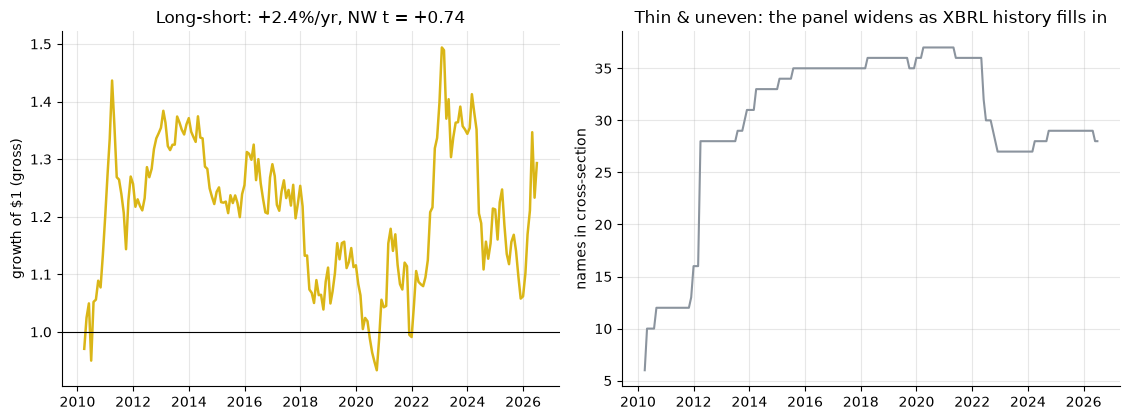

frozen: +20.1 bps/mo, NW t = +0.74, change-signal NW t = +1.79


In [2]:
if HAVE_REAL:
    ls = st.calendar_ls(PX, EV, signal_col='btd_neg', n_buckets=3, min_names=6, staleness_days=430)
    s = st.calendar_ls_stats(ls)
    ls_ch = st.calendar_ls(PX, EV, signal_col='d_btd_neg', n_buckets=3, min_names=6, staleness_days=430)
    s_ch = st.calendar_ls_stats(ls_ch)
    print(f"calendar long-short: {s['mean_bps']:+.1f} bps/mo (+{s['ann_pct']:.2f}%/yr gross), "
          f"n={s['n_months']} months, avg cross-section {s['avg_n']:.1f}")
    print(f"  one-sample t = {s['t_iid']:+.2f}   Newey-West(6) t = {s['t_nw']:+.2f}   "
          f"Sharpe {s['sharpe']:.2f}   hit {s['hit']*100:.0f}%   turnover {s['avg_turnover']:.2f}")
    print(f"  change signal (-dBTD/Assets): {s_ch['mean_bps']:+.1f} bps/mo, NW t = {s_ch['t_nw']:+.2f}, Sharpe {s_ch['sharpe']:.2f}")
    cum = (1+ls['ls']).cumprod(); nser = ls['n']
else:
    cum = None; nser = None
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
if cum is not None:
    a1.plot(cum.index, cum.values, color=AMBER, lw=1.8); a1.axhline(1, c='k', lw=.8)
    a1.set_ylabel('growth of $1 (gross)'); a1.set_title(f"Long-short: +{R['ls_ann']:.1f}%/yr, NW t = {R['ls_t_nw']:+.2f}")
    a2.plot(nser.index, nser.values, color=GREY, lw=1.5); a2.set_ylabel('names in cross-section')
    a2.set_title('Thin & uneven: the panel widens as XBRL history fills in')
else:
    for a in (a1,a2): a.text(.5,.5,'run with cache',ha='center'); a.set_axis_off()
plt.tight_layout(); plt.show()
print(f"frozen: {R['ls_mean_bps']:+.1f} bps/mo, NW t = {R['ls_t_nw']:+.2f}, "
      f"change-signal NW t = {R['change_t_nw']:+.2f}")

> 💡 In plain words: **+20 bps/month** is right-signed (low-BTD beats high-BTD, ~+2.4%/yr gross), but the HAC *t* is **+0.74** — the monthly returns are too noisy and too few (n=196, avg cross-section 30) to distinguish from zero. The strongest specification, the year-on-year **change** in the gap, only reaches NW *t* = +1.79. Right-signed, never certified.

### 4b · The cross-check — pooled event drift + placebo + monotonicity

Bucket all events by `btd_neg` (top = low BTD); top-minus-bottom forward drift with a label-shuffle null. If there were a sort, the terciles would form a ladder — the *right* way.

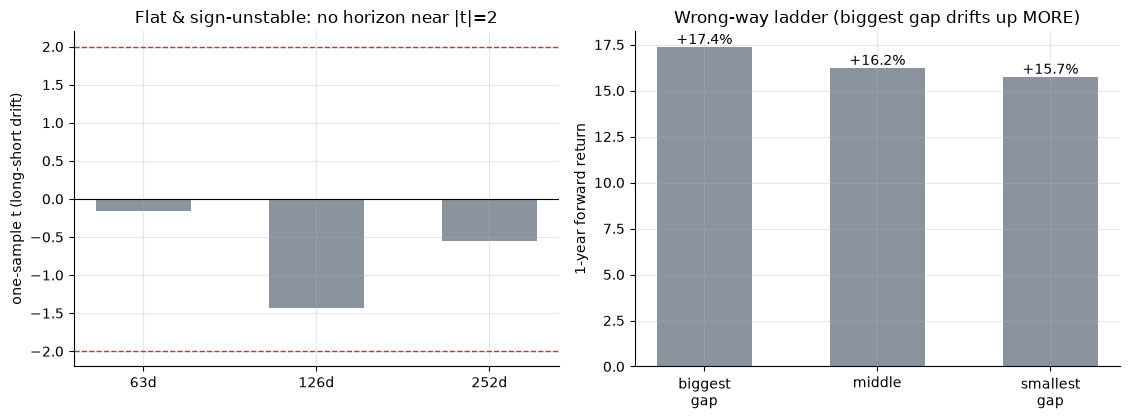

  H= 63d: long-short -0.20%  t=-0.15  win=47%  placebo p=0.564
  H=126d: long-short -2.47%  t=-1.43  win=49%  placebo p=0.940
  H=252d: long-short -1.62%  t=-0.55  win=49%  placebo p=0.731


In [3]:
rows = []
if HAVE_REAL:
    for h in st.HORIZONS:
        es = st.event_summary(PX, EV, horizon=h, n_buckets=3, n_draws=4000)
        rows.append((h, es['ls_mean']*100, es['t'], es['ls_win']*100, es['p_placebo']))
    mono = st.bucket_means(st.event_drift_frame(PX, EV, horizon=252), 3)*100
else:
    for h in st.HORIZONS:
        d = R['drift'][h]; rows.append((h, d[3], d[4], d[5], d[6]))
    mono = np.array(R['mono252'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
hs = [r[0] for r in rows]; ts = [r[2] for r in rows]
a1.bar([f'{h}d' for h in hs], ts, color=GREY, width=.55)
a1.axhline(2, ls='--', c=RED, lw=1); a1.axhline(-2, ls='--', c=RED, lw=1); a1.axhline(0, c='k', lw=.8)
a1.set_ylabel('one-sample t (long-short drift)'); a1.set_title('Flat & sign-unstable: no horizon near |t|=2')
a2.bar(['biggest\ngap','middle','smallest\ngap'], mono, color=GREY, width=.55)
for i,v in enumerate(mono): a2.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
a2.set_ylabel('1-year forward return'); a2.set_title('Wrong-way ladder (biggest gap drifts up MORE)')
plt.tight_layout(); plt.show()
for h,ls_,t,win,p in rows:
    print(f'  H={h:>3}d: long-short {ls_:+.2f}%  t={t:+.2f}  win={win:.0f}%  placebo p={p:.3f}')

> 💡 In plain words: the pooled long-short drift is **negative** at every horizon (-0.20% to -2.47%), i.e. the low-BTD names the claim says to *own* slightly *under*-perform — the opposite of the calendar sort, and still insignificant (*t* from -0.15 to -1.43, placebo *p* 0.57–0.94). The terciles run +17.4%/+16.2%/+15.7% biggest→smallest gap — a faint *anti*-Hanlon ladder. The calendar and event views disagree on sign and agree on insignificance: no return sort, either way.

### 4c · Era split — nothing hiding in a regime

Split the calendar long-short at 2018 (the TCJA statutory-rate cut, 35% → 21%).

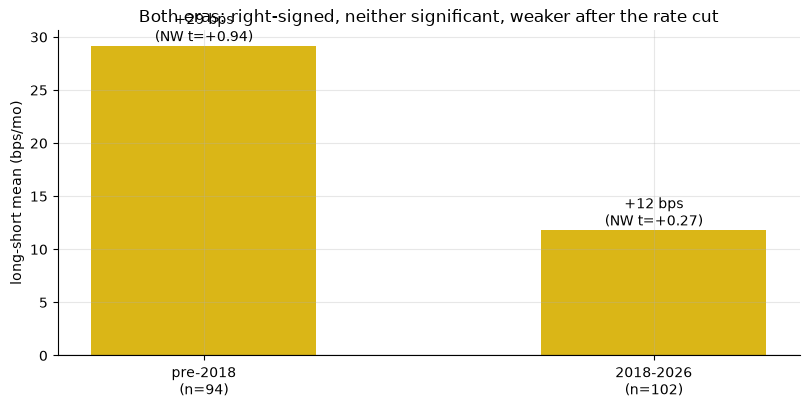

pre-2018: +29.2 bps NW t=+0.94 (n=94)  |  2018-2026: +11.8 bps NW t=+0.27 (n=102)


In [4]:
if HAVE_REAL:
    e = ls[ls.index < '2018-01-01']['ls'].to_numpy(); l = ls[ls.index >= '2018-01-01']['ls'].to_numpy()
    eb, et, en = e.mean()*1e4, st.newey_west_t(e), len(e)
    lb, lt, ln = l.mean()*1e4, st.newey_west_t(l), len(l)
else:
    eb, et, en = R['era_early_bps'], R['era_early_t'], R['era_early_n']
    lb, lt, ln = R['era_late_bps'], R['era_late_t'], R['era_late_n']
fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.bar([f'pre-2018\n(n={en})', f'2018-2026\n(n={ln})'], [eb, lb], color=[AMBER, AMBER], width=.5)
for i,(v,t_) in enumerate([(eb,et),(lb,lt)]): ax.annotate(f'{v:+.0f} bps\n(NW t={t_:+.2f})',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('long-short mean (bps/mo)')
ax.set_title('Both eras: right-signed, neither significant, weaker after the rate cut')
plt.tight_layout(); plt.show()
print(f'pre-2018: {eb:+.1f} bps NW t={et:+.2f} (n={en})  |  2018-2026: {lb:+.1f} bps NW t={lt:+.2f} (n={ln})')

> 💡 In plain words: +29 bps (NW *t* = +0.94) pre-2018, +12 bps (NW *t* = +0.27) after — the same small right-signed-but-insignificant positive, if anything *weaker* once the statutory rate dropped. It never certified in either regime.

### 4d · The mechanism — do big gaps mark *fragile* earnings?

The Hanlon headline, tested directly: an interaction OLS of next-year ROA on this-year ROA, with the persistence slope allowed to differ between the highest- and lowest-BTD terciles. Hanlon predicts the high-BTD slope is **lower**.

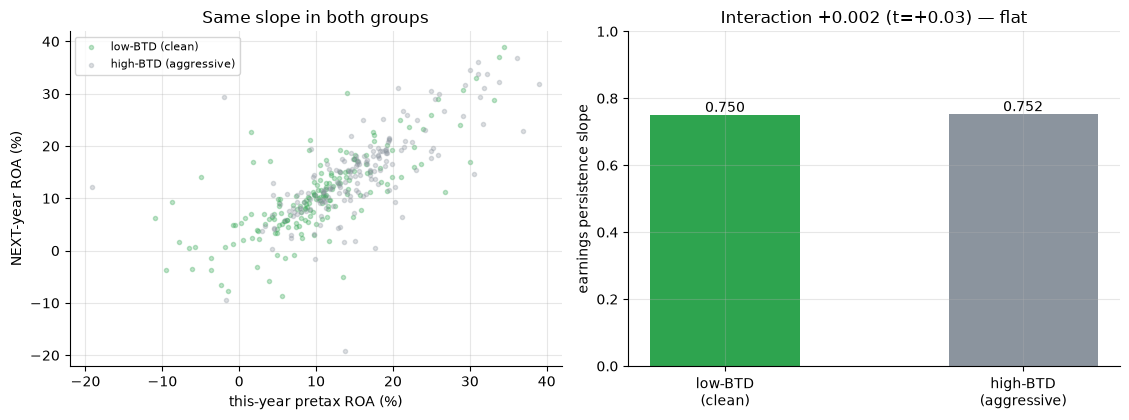

persistence: low-BTD 0.750  high-BTD 0.752  interaction +0.002 (t=+0.03)


In [5]:
if HAVE_REAL:
    q = st.earnings_persistence(EV)
    b_low, b_high, diff, tdiff = q['b_low'], q['b_high'], q['diff'], q['t_diff']
    fr = EV.dropna(subset=['roa','roa_next','btd_assets'])
    fr = fr[(fr['roa'].abs()<1)&(fr['roa_next'].abs()<1)]
    b3 = st._bucketize(fr['btd_assets'].to_numpy(), 3)
    xr, yr = fr['roa'].to_numpy(), fr['roa_next'].to_numpy()
else:
    b_low, b_high, diff, tdiff = R['b_low'], R['b_high'], R['pers_diff'], R['pers_t']
    b3 = xr = yr = None
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
if b3 is not None:
    for bk,col,lab in [(0,GREEN,'low-BTD (clean)'),(2,GREY,'high-BTD (aggressive)')]:
        m=(b3==bk)&(np.abs(xr)<.5)&(np.abs(yr)<.5)
        a1.scatter(xr[m]*100, yr[m]*100, s=9, alpha=.30, color=col, label=lab)
    a1.set_xlabel('this-year pretax ROA (%)'); a1.set_ylabel('NEXT-year ROA (%)')
    a1.set_title('Same slope in both groups'); a1.legend(fontsize=8)
else:
    a1.text(.5,.5,'run with cache',ha='center'); a1.set_axis_off()
a2.bar(['low-BTD\n(clean)','high-BTD\n(aggressive)'], [b_low, b_high], color=[GREEN, GREY], width=.5)
for i,v in enumerate([b_low,b_high]): a2.annotate(f'{v:.3f}',(i,v),ha='center',va='bottom')
a2.set_ylim(0,1.0); a2.set_ylabel('earnings persistence slope')
a2.set_title(f'Interaction {diff:+.3f} (t={tdiff:+.2f}) — flat')
plt.tight_layout(); plt.show()
print(f'persistence: low-BTD {b_low:.3f}  high-BTD {b_high:.3f}  interaction {diff:+.3f} (t={tdiff:+.2f})')

> 💡 In plain words: this is the study's decisive result — the persistence slopes are **identical** (low-BTD 0.750, high-BTD 0.752, interaction **+0.002**, *t* = +0.03). On these names a large book-tax gap does **not** mark fragile earnings. Unlike a signal whose accounting mechanism is bulletproof even when the return edge is priced away, here **even the mechanism is absent** — the return null is not 'efficiently priced real information', it's 'no information on this tape'. (Pooled *t*, so read the near-zero magnitude.)

### 4e · Tradability — the timer

For completeness, the calendar long-short net of one-way costs × turnover (both legs) + short borrow — though a sub-2 gross *t* already settles it.

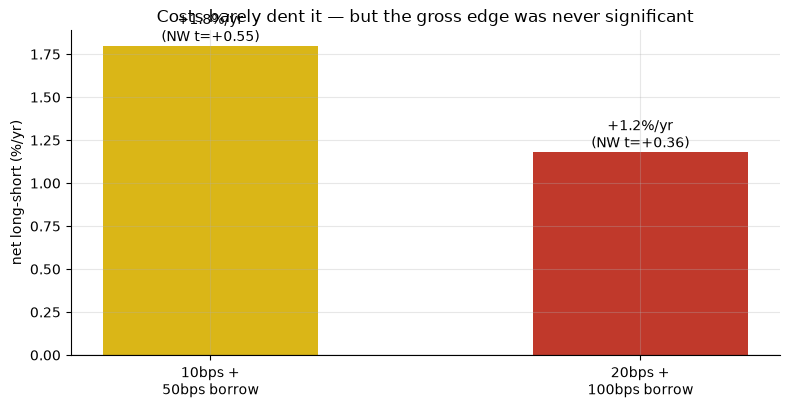

  cost 10bps + borrow 50bps/yr: +1.80%/yr net, NW t=+0.55, Sharpe 0.14
  cost 20bps + borrow 100bps/yr: +1.18%/yr net, NW t=+0.36, Sharpe 0.09


In [6]:
rows = []
if HAVE_REAL:
    for cb, bb in [(10.0,50.0),(20.0,100.0)]:
        nt = st.calendar_ls_net(ls, cost_bps=cb, borrow_bps_ann=bb)
        rows.append((cb, bb, nt['net_ann_pct'], nt['net_t_nw'], nt['net_sharpe']))
else:
    for (cb,bb),v in R['net'].items(): rows.append((cb, bb, v[1], v[2], v[3]))
labels = [f'{int(cb)}bps +\n{int(bb)}bps borrow' for cb,bb,_,_,_ in rows]
anns = [r[2] for r in rows]
fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.bar(labels, anns, color=[AMBER, RED], width=.5)
for i,(cb,bb,a,t,sh) in enumerate(rows): ax.annotate(f'+{a:.1f}%/yr\n(NW t={t:+.2f})',(i,a),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('net long-short (%/yr)')
ax.set_title('Costs barely dent it — but the gross edge was never significant')
plt.tight_layout(); plt.show()
for cb,bb,a,t,sh in rows: print(f'  cost {int(cb)}bps + borrow {int(bb)}bps/yr: +{a:.2f}%/yr net, NW t={t:+.2f}, Sharpe {sh:.2f}')

> 💡 In plain words: turnover is low (~0.05/mo — a slow annual balance-sheet signal), so costs only trim ~+1.2%/yr. But that's irrelevant: net NW *t* = +0.36, and you cannot be paid for a spread that wasn't distinguishable from zero to begin with. **Tradability = MIRAGE.**

### 4f · Faithful-engine & power control

Synthetic price + signal panel with a TUNABLE planted Hanlon effect (low-BTD names drift up). The null (edge = 0) is checked over **12 seeds**.

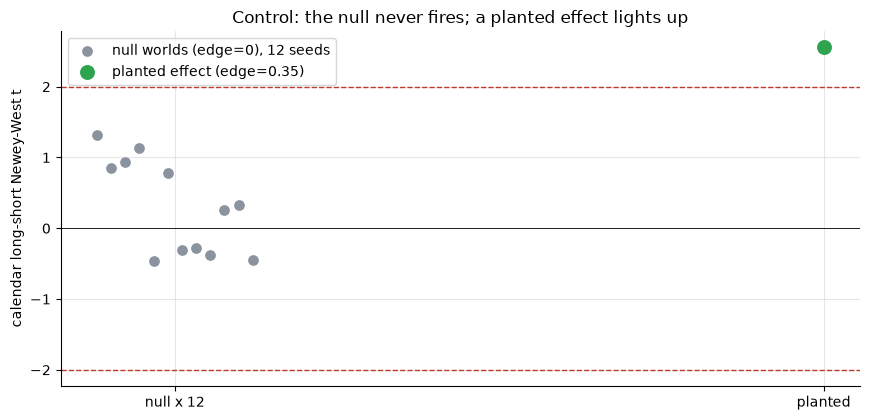

null: mean NW t = +0.31 (sd 0.67), |t|>=2 in 0/12  |  planted NW t = +2.55


In [7]:
null_ts = []
for s_ in range(12):
    p0, e0 = data.synthetic_panel(edge=0.0, seed=856 + s_)
    null_ts.append(st.synthetic_detect(p0, e0)['t_nw'])
null_ts = np.asarray(null_ts)
p1, e1 = data.synthetic_panel(edge=0.35, seed=856)
planted_t = st.synthetic_detect(p1, e1)['t_nw']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.linspace(-.12,.12,12), null_ts, color=GREY, s=45, label='null worlds (edge=0), 12 seeds')
ax.scatter([1], [planted_t], color=GREEN, s=95, zorder=5, label='planted effect (edge=0.35)')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(0, c='k', lw=.6)
ax.set_xticks([0,1]); ax.set_xticklabels(['null x 12','planted'])
ax.set_ylabel('calendar long-short Newey-West t')
ax.set_title('Control: the null never fires; a planted effect lights up'); ax.legend()
plt.tight_layout(); plt.show()
print(f'null: mean NW t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/12  |  planted NW t = {planted_t:+.2f}')

> 💡 In plain words: across 12 null worlds the detector averages NW *t* = +0.31 (sd 0.67) and crosses |t|=2 **0/12** times; a planted effect reads NW *t* = 2.55. The machinery is unbiased and powered, so the real-tape +0.74 is a genuine near-null, not a broken pipeline. *(Power check only — never cited in support of a real-tape stamp.)*

## 5 · The verdict

- **Signal (returns) `WEAK`** — calendar tercile long-short +20.1 bps/mo (+2.4%/yr gross), one-sample *t* = +0.75, **Newey-West *t* = +0.74**; change variant NW *t* = +1.79; pooled event drift **mildly anti-Hanlon** and insignificant (placebo *p* > 0.5); both eras right-signed but insignificant. Right sign not even stable across methods — tape-uncertified.
- **Tradability `MIRAGE`** — net of 20 bps + 100 bps borrow: +1.18%/yr, NW *t* = +0.36, Sharpe 0.09; fails before costs.
- **Marks fragile earnings? `NOT DETECTED`** — persistence interaction +0.002 (*t* = +0.03); high-BTD 0.752 vs low-BTD 0.750. The mechanism that anchors the claim is flat on blue chips.

## 6 · Going further

- **Where the effect probably still lives** is the **broad cross-section** Hanlon studied — small, distressed, tax-shelter-heavy names with genuinely large, under-scrutinised book-tax gaps. A large-cap *survivor* basket is the hardest possible test: these are the firms where the gap is smallest, best-explained and most-watched. The null here refutes the **blue-chip** version, not the anomaly itself.
- **Coverage honesty:** the cross-section runs ≈6 → 37 names, three names lack a clean pretax-income tag, and the statutory-rate gross-up ignores the 2018 blended-rate year. A wider, survivorship-free panel with hand-checked tax footnotes is the honest next step.
- **Dedup map:** [568-effective-tax-rate](../../568-effective-tax-rate/) (the tax *rate* level/change, not the book-tax *gap*), [231-sloan-accruals](../../231-sloan-accruals/) (total accruals, the family BTD is a tax-specific slice of), [229-beneish-m-score](../../229-beneish-m-score/) (an eight-signal manipulation score). None ranks on the statutory-grossed-up book-minus-tax income gap.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*